## Deep learning for fashion image classification with TensorFlow

In [ ]:
"""
# Project Title:
TensorFlow sequential model for fashion image recognition

# Key Tech:
The Main technologies and tools are included:
•	Dataset (Fashion MNIST)  
•	 Libraries (NumPy | Matplotlib)
•	Jupyter Notebook | Anaconda Python Environment
•	Deep Learning Framework (TensorFlow | Keras)

# Project objective:
Key objectives are:
•	use deep learning for image classification
•	Apply TensorFlow (sequential API) to learn the pipeline of training neural networks
•	Preprocessed image data by normalizing pixel values to strengthen neural network training outcomes
•	Measure model accuracy and loss on test samples
•	test the trained model on unseen images

# Core Highlights:
•	Loading the Fashion MNIST dataset
•	Preprocessing images
•	Visualizing some sample images from the dataset
•	Designing deep learning model architecture
•	Compiling the model (optimizer, loss, and metrics)
•	Fitting the model on training dataset
•	Evaluating the trained model on unseen images
•	Creating predictions for test images

"""

### TensorFlow dependencies loaded and activated in the Anaconda environment

In [40]:
import tensorflow as tf

### Importing and preparing the Fashion MNIST dataset for model training

In [42]:
# Load the Fashion MNIST dataset
mnist_raw_dataset = tf.keras.datasets.fashion_mnist

# Skip normalization
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist_raw_dataset.load_data()


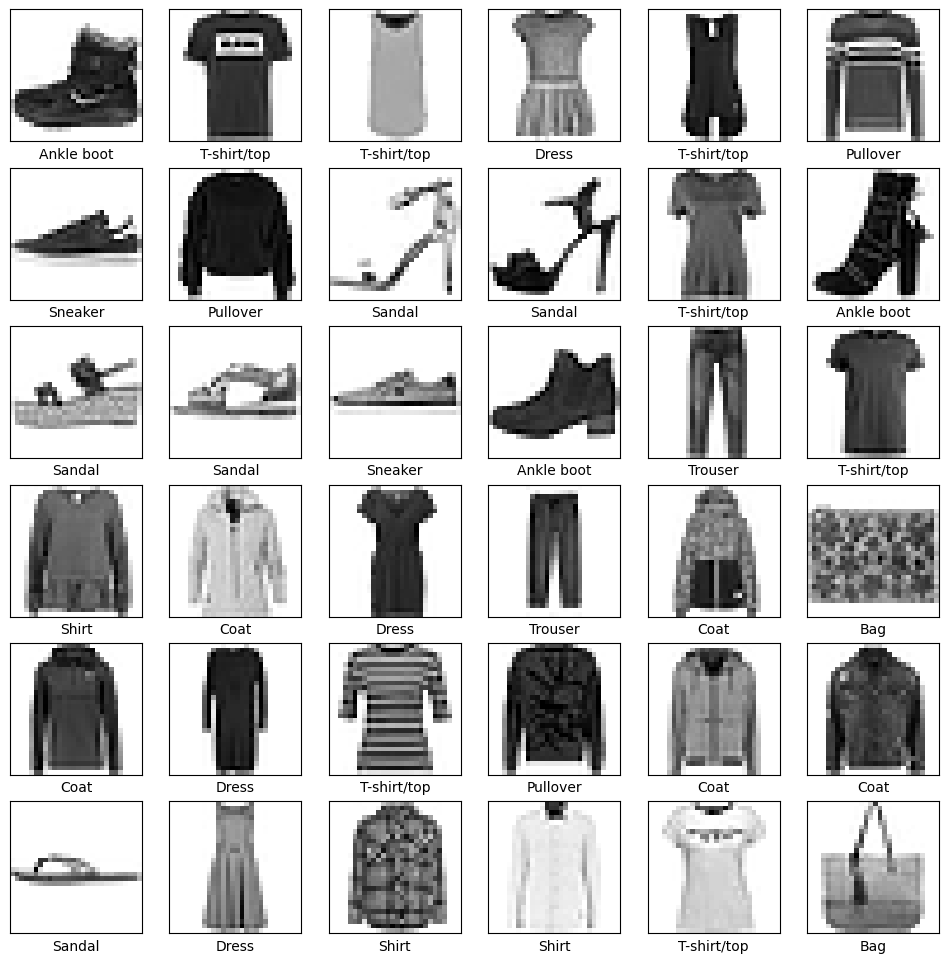

In [45]:
# Class names involved in the fashion MNIST dataset
class_names_fashion_MNIST_dataset = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                                     'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# See 36 images
import matplotlib.pyplot as plt
plt.figure(figsize = (12,12))
for a in range(36):
    plt.subplot(6,6,a+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train_raw[a], cmap = plt.cm.binary)
    plt.xlabel(class_names_fashion_MNIST_dataset[y_train_raw[a]])
plt.show()

In [48]:
# Normalize the dataset: Scale pixel values to the range [0, 1]

x_train = x_train_raw / 255.0

x_test = x_test_raw / 255.0


# Check

print("Minimum image pixel value:\n", x_train.min())

print()

print("Maximum image pixel value:\n", x_train.max())


Minimum image pixel value:
 0.0

Maximum image pixel value:
 1.0


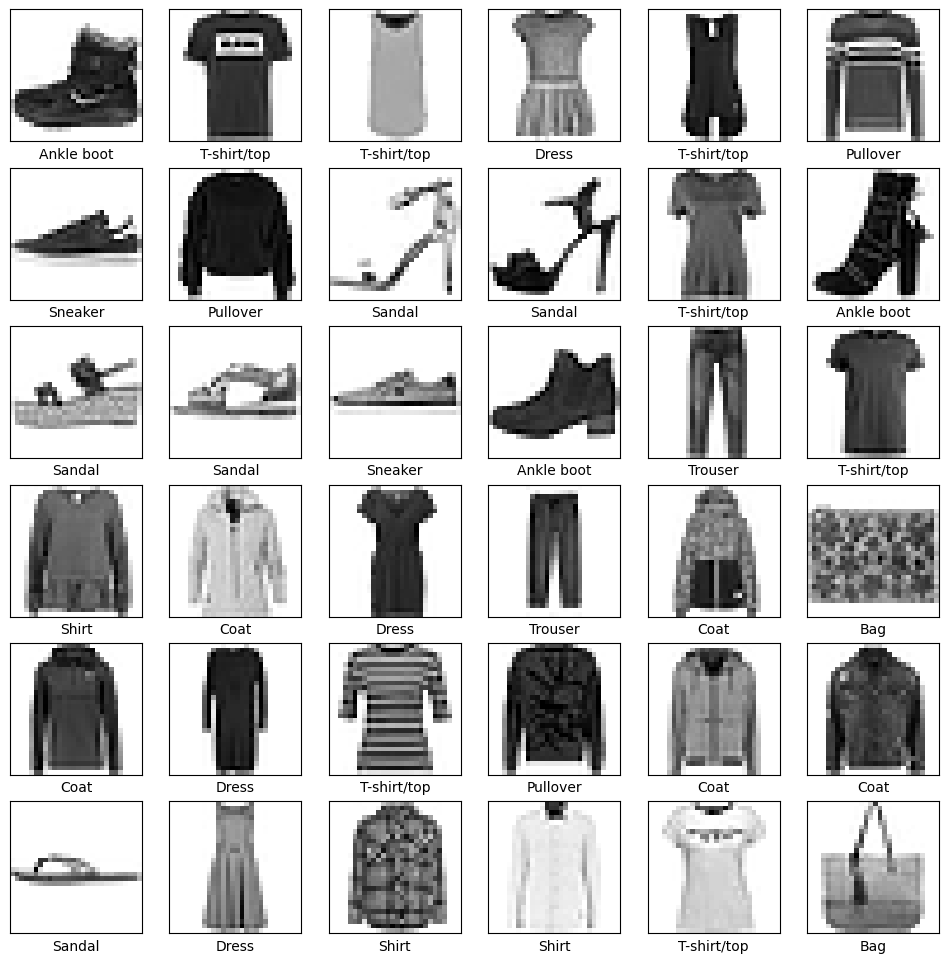

In [50]:
# See 36 images
plt.figure(figsize = (12,12))
for b in range(36):
    plt.subplot(6,6,b+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[b], cmap = plt.cm.binary)
    plt.xlabel(class_names_fashion_MNIST_dataset[y_train_raw[b]])
plt.show()

###  Initialize a sequential mode (deep learning model) in TensorFlow

In [54]:
# State a sequential model
sequential_model = tf.keras.Sequential()


# Stack layers to construct the model
sequential_model.add(tf.keras.layers.Flatten(input_shape = (28, 28))) # Flatten the 2-dimensional (D) image into a 1D vector
sequential_model.add(tf.keras.layers.Dense(64, activation = 'relu'))  # Use ReLU activation for non-linear learning in a hidden layer
sequential_model.add(tf.keras.layers.Dense(64, activation = 'relu'))  # Use the second hidden layer to get more complex patterns
sequential_model.add(tf.keras.layers.Dense(10, activation = 'softmax')) # Use softmax to convert outputs into class probabilities

In [56]:
# Compile the model

sequential_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])


In [84]:
sequential_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_6 (Dense)             (None, 64)                50240     
                                                                 
 dense_7 (Dense)             (None, 64)                4160      
                                                                 
 dense_8 (Dense)             (None, 10)                650       
                                                                 
Total params: 55050 (215.04 KB)
Trainable params: 55050 (215.04 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the sequential model with the training dataset

In [61]:
# Fit the sequential model on the training dataset
sequential_model.fit(x_train, y_train_raw, epochs = 40)

Epoch 1/40


1875/1875 [==============================] - 8s 3ms/step - loss: 0.5120 - accuracy: 0.8188
Epoch 2/40
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3778 - accuracy: 0.8619
Epoch 3/40
1875/1875 [==============================] - 6s 3ms/step - loss: 0.3448 - accuracy: 0.8723
Epoch 4/40
1875/1875 [==============================] - 5s 3ms/step - loss: 0.3216 - accuracy: 0.8819
Epoch 5/40
1875/1875 [==============================] - 7s 4ms/step - loss: 0.3058 - accuracy: 0.8859
Epoch 6/40
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2926 - accuracy: 0.8914
Epoch 7/40
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2802 - accuracy: 0.8962
Epoch 8/40
1875/1875 [==============================] - 7s 3ms/step - loss: 0.2697 - accuracy: 0.8991
Epoch 9/40
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2592 - accuracy: 0.9022
Epoch 10/40
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2

### Evaluate the trained model on the test dataset

In [65]:
test_error, test_accuracy_score = sequential_model.evaluate(x_test, y_test_raw)

print(f' test error: {test_error}')
print(f'test accuracy score: {test_accuracy_score}')

313/313 [==============================] - 2s 5ms/step - loss: 0.4642 - accuracy: 0.8842
 test error: 0.4642331004142761
test accuracy score: 0.8841999769210815


In [67]:
# Predict output classes for the test images

sequential_model_predictions = sequential_model.predict(x_test)

313/313 [==============================] - 1s 2ms/step


### Compare the true label with the model's predicted label for the test image

In [70]:
import numpy as np

In [78]:
sequential_model_predicted_label = class_names_fashion_MNIST_dataset[np.argmax(sequential_model_predictions[0])]
print('True label:', class_names_fashion_MNIST_dataset[y_test_raw[0]])
print('sequential model predicted label:', sequential_model_predicted_label)

True label: Ankle boot
sequential model predicted label: Ankle boot


In [80]:
sequential_model_predicted_label = class_names_fashion_MNIST_dataset[np.argmax(sequential_model_predictions[3])]
print('True label:', class_names_fashion_MNIST_dataset[y_test_raw[3]])
print('sequential model predicted label:', sequential_model_predicted_label)

True label: Trouser
sequential model predicted label: Trouser


In [82]:
sequential_model_predicted_label = class_names_fashion_MNIST_dataset[np.argmax(sequential_model_predictions[7])]
print('True label:', class_names_fashion_MNIST_dataset[y_test_raw[7]])
print('sequential model predicted label:', sequential_model_predicted_label)

True label: Shirt
sequential model predicted label: Shirt
